In [1]:
%load_ext autoreload
%autoreload 2

# XTCAV Processing: Physical Units

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import psana

# XTCAV Processor Class
from xtcav_processor import XTCAVProcessor
from xtcav_dark_reference import XTCAVDarkReference
get_datasource = lambda runnum: psana.DataSource(f"exp=cxil1037623:run={runnum}:idx")

## Get Dark Reference

XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV


Setting up data run times...
Done.


Setting data source types...: 10322it [00:00, 25354.36it/s]                       


Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>


Calculating dark reference: 100%|█████████▉| 999/1000 [00:03<00:00, 300.29it/s]



Maximum number of images processed



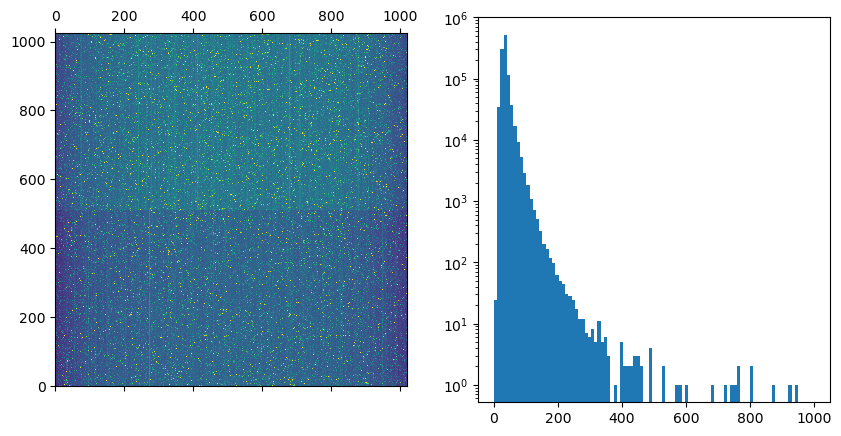

In [6]:
xtdr = XTCAVDarkReference(get_datasource(215), max_shots=1000, _test_xy=True)

xtdr.show(
    vrange = (0,1e2),
    bins = np.linspace(0,1000,100)
)

## Setup lasing-off run

To test lasing off runs, we should start with the best/easiest data.  We'll want well separated pulses (i.e. not the zero time delay data), and clean, wide pulses.  Good options are:
- epoch E: 153
- epoch I: 270
- epoch J: 294

Let's start with epoch I (run 270), which has very well separated pulses, and fairly different structures for the two pulses, with a very clean and comparatively wide leading pulse.

XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV


Setting up data run times...
Done.


Setting data source types...: 4212it [00:00, 16946.11it/s]                       


Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>
Looping through the first 1 good events...
Showing good shot #1 at time index 187:


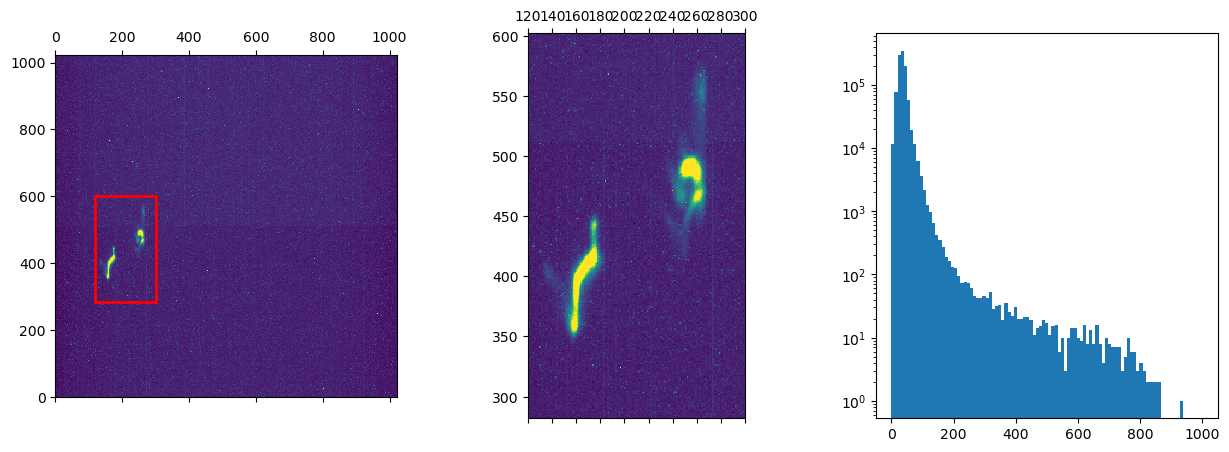

In [24]:
# Create the XTCAV processor
xtpr = XTCAVProcessor(get_datasource(270), _test_xy=True)
# xtpr.reset_shot_iterator()

# Get and show some data
n_shots_show = 1
fov = 180,320

print(f"Looping through the first {n_shots_show} good events...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get & show event
    xtpr.set_current_event(evt)
    xtpr.show_current_frame(vrange=(0,350),bins=np.linspace(0,1000,100),fov=fov)

    # continue?
    if idx>=n_shots_show-1:
        break

### Link & subtract background

Looping through the first 3 good events...
Showing good shot #1 at time index 187:


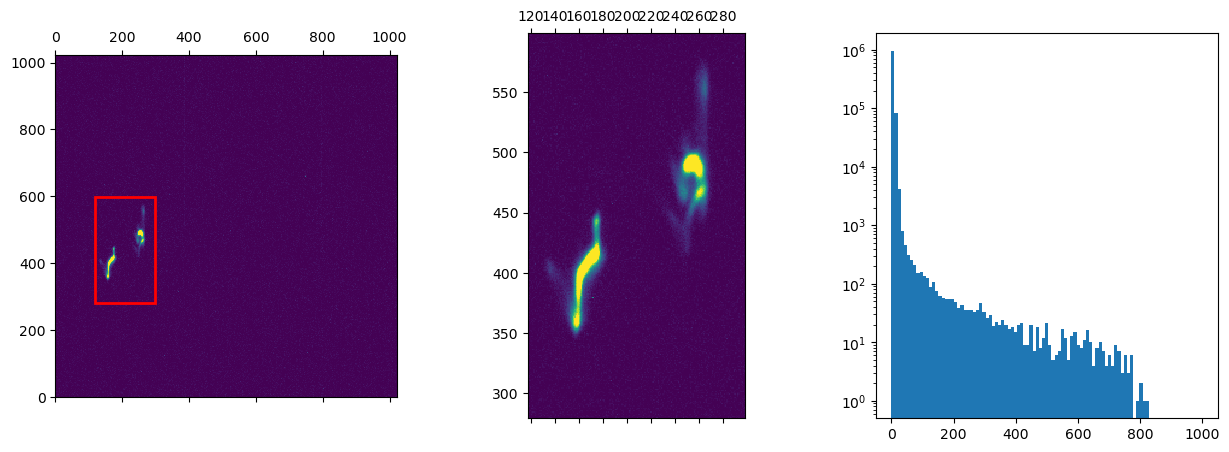

Showing good shot #2 at time index 188:


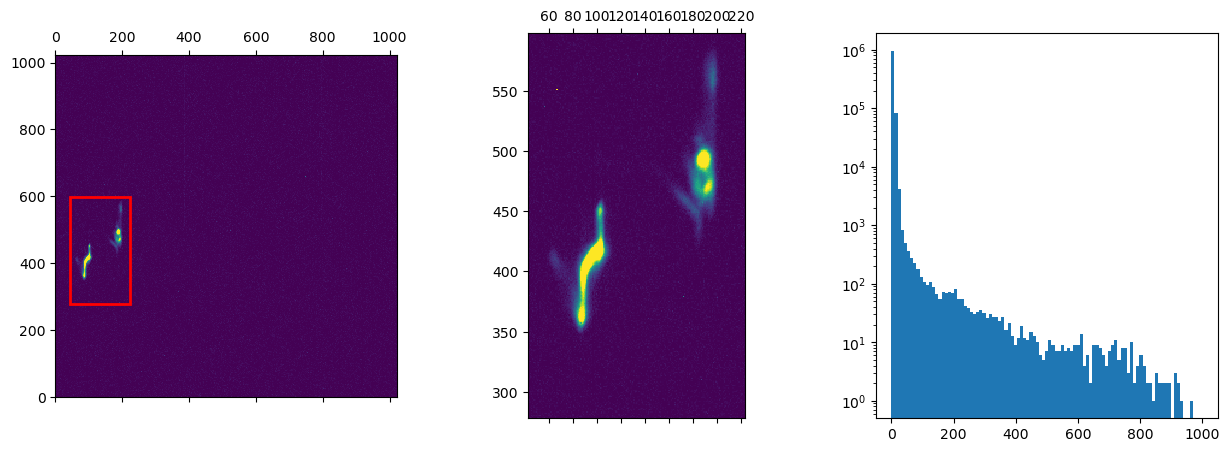

Showing good shot #3 at time index 189:


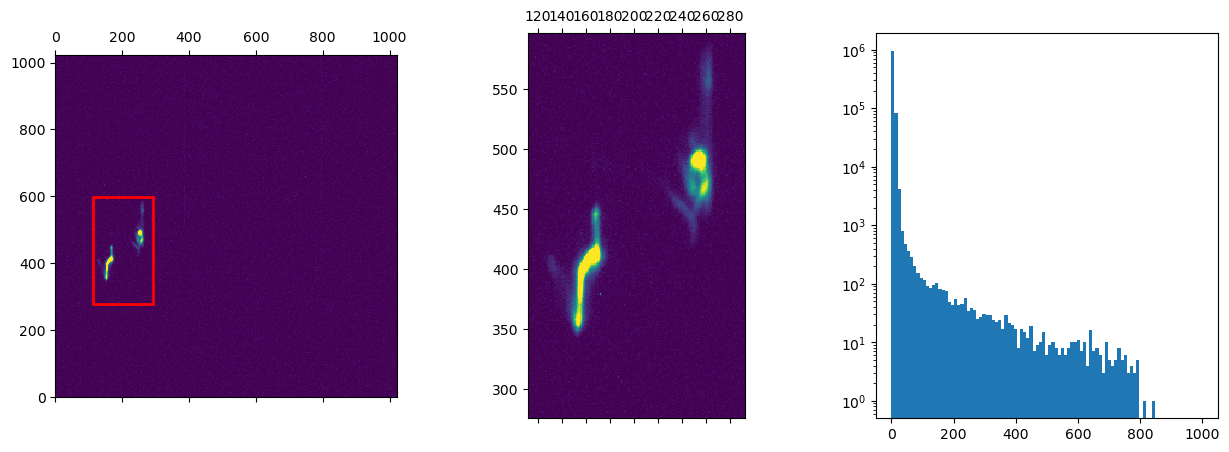

In [25]:
# Set dark reference
xtpr.set_darkreference(xtdr)

# Get and show some data
xtpr.reset_shot_iterator()
n_shots_show = 3

print(f"Looping through the first {n_shots_show} good events...")
for idx,(i,j,evt) in enumerate(xtpr.shot_iterator):
    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get & show event
    xtpr.set_current_event(evt)
    xtpr.show_current_frame(vrange=(0,350),bins=np.linspace(0,1000,100),fov=fov,preprocess='bksb')

    # continue?
    if idx>=n_shots_show-1:
        break

### Denoise image

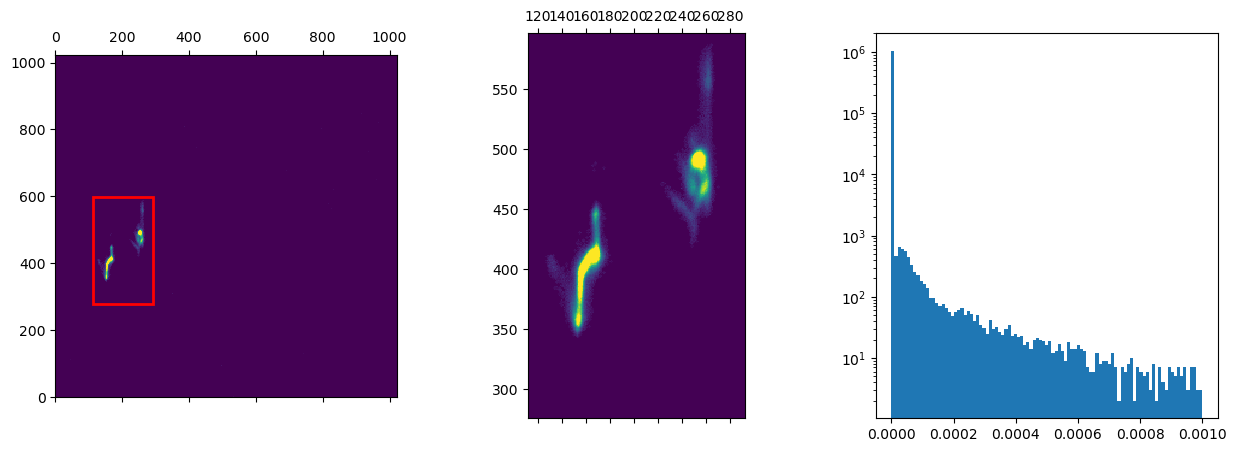

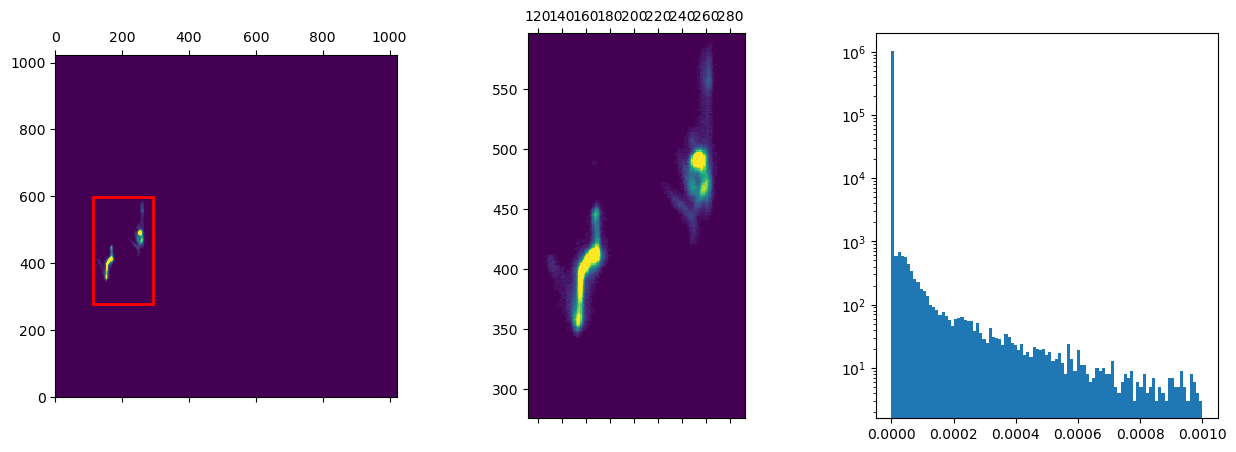

In [26]:
# Get and show background subtracted and denoised images

# ...with default denoising params
xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(),
    vrange=(0,6e-4),
    bins=np.linspace(0,1e-3,100),
    fov=fov
)

# ...with tweaked denoising params
xtpr.show_frame(
    frame = xtpr.get_frame_denoised_current(nstd=1,close=2),
    vrange=(0,6e-4),
    bins=np.linspace(0,1e-3,100),
    fov=fov
)

### Split images

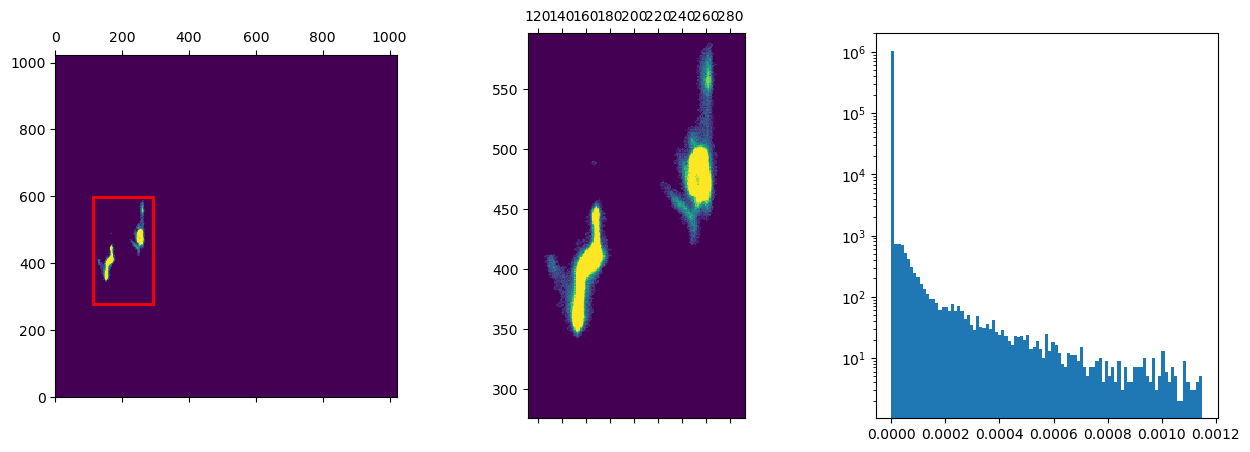

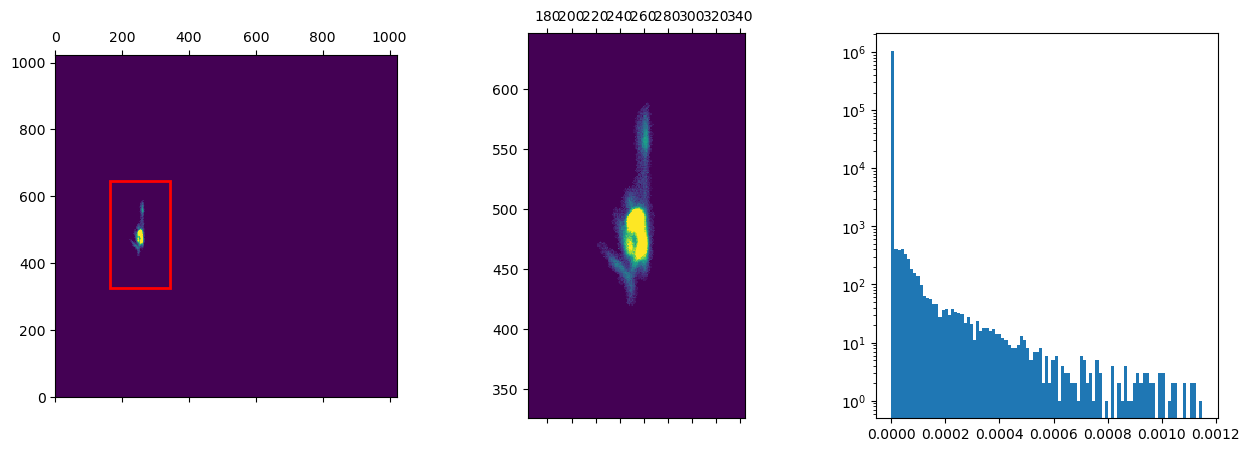

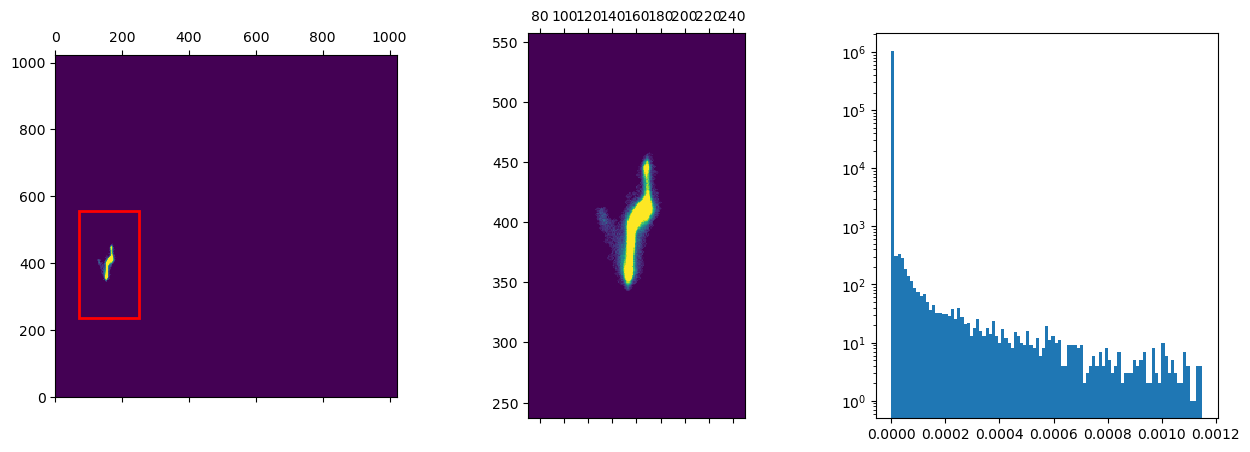

In [27]:
# Get a denoised frame & split the pulses
im = xtpr.get_frame_denoised_current(nstd=1,close=2)
ims = xtpr.split_frame(im,2)

# Show
xtpr.show_frame(
    im,
    vrange=(0,2e-4),
    bins=np.linspace(0,1.15e-3,100),
    fov=fov,
)
xtpr.show_frame(
    ims[0],
    vrange=(0,3e-4),
    bins=np.linspace(0,1.15e-3,100),
    fov=fov,
)
xtpr.show_frame(
    ims[1],
    vrange=(0,3e-4),
    bins=np.linspace(0,1.15e-3,100),
    fov=fov,
)

### Get image statistics

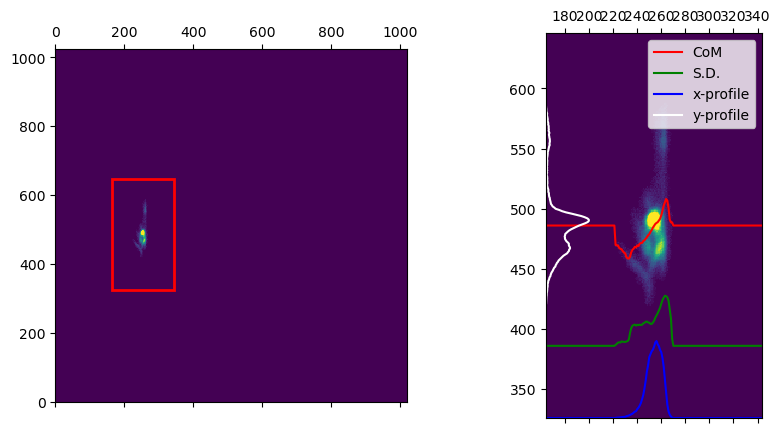

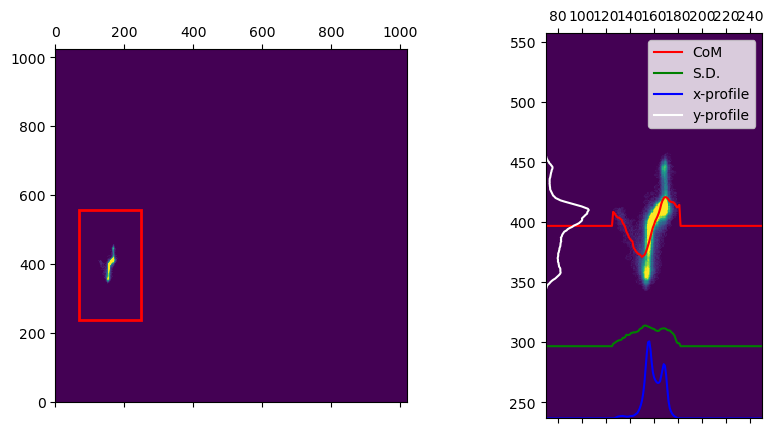

In [29]:
frame1,frame2 = ims[0],ims[1]

imageStats1 = xtpr.get_pulse_statistics(frame1)
imageStats2 = xtpr.get_pulse_statistics(frame2)
xtpr.show_frame_statistics(frame1,imageStats1,vrange=(0,6e-4),fov=fov,profiles=True)
xtpr.show_frame_statistics(frame2,imageStats2,vrange=(0,6e-4),fov=fov,profiles=True)

# Get physical units

In [10]:
def CalculatePhysicalUnits(self, center, shotToShot, globalCalibration):
    """
    Calculate physical units for the x (time) and y (energy) axes.

    Parameters
    ----------
    center : len-2 array
        Coordinates of the center of mass
    shotToShot : dict
        Properties of the specific shot
    globalCalibration : dict
        Global calibrations for the xtcav
    
    Returns
    -------
    2-tuple : (dict, bool)
        (physical units, success flag)
    """
    ok=1
 
    umperpix=globalCalibration['umperpix']
    dumpe=globalCalibration['dumpe']
    dumpdisp=globalCalibration['dumpdisp']    
    rfampcalib=globalCalibration['rfampcalib']
    rfphasecalib=globalCalibration['rfphasecalib']    
    strstrength=globalCalibration['strstrength']
    
    rfamp=shotToShot['xtcavrfamp']
    rfphase=shotToShot['xtcavrfphase']

    yMeVPerPix = umperpix*dumpe/dumpdisp*1e-3;          #Spacing of the y axis in MeV
    
    xfsPerPix = -umperpix*rfampcalib/(0.3*strstrength*rfamp);     #Spacing of the x axis in fs (this can be negative)
    
    cosphasediff=math.cos((rfphasecalib-rfphase)*math.pi/180)

    #If the cosine of phase was too close to 0, we return warning and error
    if np.abs(cosphasediff)<0.5:
        warnings.warn_explicit('The phase of the bunch with the RF field is far from 0 or 180 degrees',UserWarning,'XTCAV',0)
        ok=0

    signflip = np.sign(cosphasediff); #It may need to be flipped depending on the phase

    xfsPerPix = signflip*xfsPerPix;    
    
    xfs=xfsPerPix*(self.x-center[0])                  #x axis in fs around the center of mass
    yMeV=yMeVPerPix*(self.y-center[1])                #y axis in MeV around the center of mass
           
    
    physicalUnits={                                     #Structure with the physical units
        'yMeVPerPix':yMeVPerPix,
        'xfsPerPix':xfsPerPix,
        'xfs':xfs,
        'yMeV':yMeV
        }
           
           
    return physicalUnits,ok

In [11]:
ebeam, gasdetector, frame = xtpr.get_data(evt)
shotToShot,ok = xtpr._get_shot_to_shot_parameters(ebeam,gasdetector)

globalCalibrations = xtpr._global_calibrations

In [12]:
print(globalCalibrations)

{'umperpix': 3.48929741288637e-310, 'strstrength': 112.51891074130106, 'rfampcalib': 80.0, 'rfphasecalib': 90.0, 'dumpe': 0, 'dumpdisp': 0.48326069512019}


In [13]:
print(shotToShot)

{'ebeamcharge': 0.1985805160704, 'dumpecharge': 1.4351263665788828e-10, 'xtcavrfamp': 0.0, 'xtcavrfphase': 0.0, 'xrayenergy': -3.949678042403093e-06}


In [14]:
imageStats = imageStats1

center = np.array([imageStats['xCOM'],imageStats['yCOM']])
center

array([253.80427994, 486.09356371])

In [15]:
CalculatePhysicalUnits(xtpr, center, shotToShot, globalCalibrations)

ZeroDivisionError: float division by zero

### RF amplitude metadata problems...

The rf amplitude and phase in the shot-to-shot metadata is recorded as zero in every event I've looked at.  Is this true for all the datasets?

In [15]:
from tqdm import tqdm

In [20]:
# xtpr = XTCAVProcessor(get_datasource(270))
# xtpr = XTCAVProcessor(get_datasource(271))
# xtpr = XTCAVProcessor(get_datasource(76))
xtpr = XTCAVProcessor(get_datasource(77))


# Get and show some data
xtpr.reset_shot_iterator()
n_shots = 1000

shot_index = []
xtcav_rfamp = []
xtcav_rfphase = []

print(f"Looping through the first {n_shots} good events...")
for idx,(i,j,evt) in enumerate(tqdm(xtpr.shot_iterator,total=n_shots)):
#    print(f"Showing good shot #{i+1} at time index {j}:")

    # Get event & shot metadata
    xtpr.set_current_event(evt)
    ebeam, gasdetector, frame = xtpr.get_data(evt)
    shotToShot,ok = xtpr._get_shot_to_shot_parameters(ebeam,gasdetector)

    # Record
    rfamp=shotToShot['xtcavrfamp']
    rfphase=shotToShot['xtcavrfphase']
    shot_index.append(j)
    xtcav_rfamp.append(rfamp)
    xtcav_rfphase.append(rfphase)
    
    # continue?
    if idx>=n_shots-1:
        break

print(np.sum(xtcav_rfamp))
print(np.sum(xtcav_rfphase))

XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV


Setting up data run times...
Done.


Setting data source types...: 50381it [00:16, 2970.53it/s]                         


Data source types successfully set.
Electron beam source type is <class 'psana.Bld.BldDataEBeamV7'>
Gas detector source type is <class 'psana.Bld.BldDataFEEGasDetEnergyV1'>
Looping through the first 1000 good events...


100%|█████████▉| 999/1000 [01:34<00:00, 10.57it/s]

0.0
0.0


In [22]:
runnums = [11,93,117,121,153,156,183,184,216,220,245,272,294,298,]

n_shots = 100

for runnum in runnums:

    print(f"Testing run {runnum}...")
    xtpr = XTCAVProcessor(get_datasource(runnum),verbose=False)
    for idx,(i,j,evt) in enumerate(tqdm(xtpr.shot_iterator,total=n_shots)):
    
        # Get event & shot metadata
        xtpr.set_current_event(evt)
        ebeam, gasdetector, frame = xtpr.get_data(evt)
        shotToShot,ok = xtpr._get_shot_to_shot_parameters(ebeam,gasdetector)
    
        # Record
        rfamp=shotToShot['xtcavrfamp']
        rfphase=shotToShot['xtcavrfphase']
        shot_index.append(j)
        xtcav_rfamp.append(rfamp)
        xtcav_rfphase.append(rfphase)
        
        # continue?
        if idx>=n_shots-1:
            break

    print(f"...found sum(rfAmp)={np.sum(xtcav_rfamp)} and sum(rfPhase)={np.sum(xtcav_rfphase)}")
    print()

Testing run 11...


XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV

 99%|█████████▉| 99/100 [00:01<00:00, 73.52it/s] 


...found sum(rfAmp)=0.0 and sum(rfPhase)=0.0

Testing run 93...


XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV

 99%|█████████▉| 99/100 [00:01<00:00, 86.13it/s] 


...found sum(rfAmp)=0.0 and sum(rfPhase)=0.0

Testing run 117...


...

...found sum(rfAmp)=0.0 and sum(rfPhase)=0.0

Testing run 294...


XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV

 99%|█████████▉| 99/100 [00:01<00:00, 62.79it/s]


...found sum(rfAmp)=0.0 and sum(rfPhase)=0.0

Testing run 298...


XTCAV:0: UserWarning: No XTCAV Calibration for epics variable XTCAV_Beam_energy_dump_GeV

 99%|█████████▉| 99/100 [00:15<00:00,  6.55it/s]

...found sum(rfAmp)=0.0 and sum(rfPhase)=0.0



# Sandbox

## Epics store

Stores the state of all EPICS info

In [9]:
#epicsStore = dataSource.env().epicsStore()
epicsStore = xtpr._env.epicsStore()

epicsStore

EpicsStore()

In [10]:
epicsStore?

Type:        EpicsStore
String form: EpicsStore()
File:        /sdf/group/lcls/ds/ana/sw/conda1/inst/envs/ana-4.0.66-py3/lib/python3.9/site-packages/psana/__init__.py
Docstring:   Wrapper for C++ class PSEnv::EpicsStore. This class stores state of all EPICS corresponding to current event.

In [11]:
epicsStore.aliases()[:5]

['CsPadTripper_Active',
 'CsPadTripper_NPixels',
 'CsPadTripper_PixelThreshold',
 'CsPadTripper_State',
 'Dg1Pim_y']

In [12]:
epicsStore.names()[:5]

['AT1L0:SOLID:MPA:01:POS_STATE_RBV',
 'AT1L0:SOLID:MPA:02:POS_STATE_RBV',
 'AT1L0:SOLID:MPA:03:POS_STATE_RBV',
 'AT1L0:SOLID:MPA:04:POS_STATE_RBV',
 'AT1L0:SOLID:MPA:05:POS_STATE_RBV']

In [13]:
epicsStore.pvNames()[:5]

['AT1L0:SOLID:MPA:01:POS_STATE_RBV',
 'AT1L0:SOLID:MPA:02:POS_STATE_RBV',
 'AT1L0:SOLID:MPA:03:POS_STATE_RBV',
 'AT1L0:SOLID:MPA:04:POS_STATE_RBV',
 'AT1L0:SOLID:MPA:05:POS_STATE_RBV']

In [14]:
print(epicsStore.value('Dg1Pim_y'))
print(epicsStore.value('AT1L0:SOLID:MPA:05:POS_STATE_RBV'))

-0.0004164062499967258
0


## Global calibration

In [ ]:
#globalCalibration,ok = xtup.GetGlobalXTCAVCalibration(epicsStore)

In [ ]:
def GetGlobalXTCAVCalibration(epicsStore):
    """
    Obtain the global XTCAV calibration form the epicsStore
    Arguments:
      epicsStore
    Output:
      globalCalibration: struct with the parameters
      ok: if all the data was retrieved correctly
    """
    

    ok = [1]
    umperpix=GetGlobalCalibValue(epicsStore,['XTCAV_calib_umPerPx','OTRS:DMP1:695:RESOLUTION'],ok)
    strstrength=GetGlobalCalibValue(epicsStore,['XTCAV_strength_par_S','Streak_Strength','OTRS:DMP1:695:TCAL_X'],ok)
    rfampcalib=GetGlobalCalibValue(epicsStore,['XTCAV_Amp_Des_calib_MV','XTCAV_Cal_Amp','SIOC:SYS0:ML01:AO214'],ok)
    rfphasecalib=GetGlobalCalibValue(epicsStore,['XTCAV_Phas_Des_calib_deg','XTCAV_Cal_Phase','SIOC:SYS0:ML01:AO215'],ok)
    dumpe=GetGlobalCalibValue(epicsStore,['XTCAV_Beam_energy_dump_GeV','Dump_Energy','REFS:DMP1:400:EDES'],ok)
    dumpdisp=GetGlobalCalibValue(epicsStore,['XTCAV_calib_disp_posToEnergy','Dump_Disp','SIOC:SYS0:ML01:AO216'],ok)

    globalCalibration={
        'umperpix':umperpix, #Pixel size of the XTCAV camera
        'strstrength':strstrength,  #Strength parameter
        'rfampcalib':rfampcalib,    #Calibration of the RF amplitude
        'rfphasecalib':rfphasecalib,    #Calibration of the RF phase
        'dumpe':dumpe,                  #Beam energy: dump config
        'dumpdisp':dumpdisp             #Vertical position to energy: dispersion
        }
                
                
    return globalCalibration,ok[0]

## Shot-to-shot parameters

In [ ]:
shotToShot,ok = xtup.ShotToShotParameters(ebeam,gasdetector)

In [ ]:
def ShotToShotParameters(ebeam,gasdetector):
    """
    Obtain shot to shot parameters
    Arguments:
      ebeam: psana.Bld.BldDataEBeamV5
      gasdetector: psana.Bld.BldDataFEEGasDetEnergy
    Output:
      ROI: struct with the ROI
      ok: if all the data was retrieved correctly
    """
    ok=1
    echarge=1.60217657e-19;

    if ebeam:    
        ebeamcharge=ebeam.ebeamCharge()
        xtcavrfamp=ebeam.ebeamXTCAVAmpl()
        xtcavrfphase=ebeam.ebeamXTCAVPhase()
        dumpecharge=ebeam.ebeamDumpCharge()*echarge #In C        
    else:    #Some hardcoded values
        warnings.warn_explicit('No ebeamv info',UserWarning,'XTCAV',0)
        ok=0
        ebeamcharge=5
        xtcavrfamp=20
        xtcavrfphase=90
        energydetector=0.2;
        dumpecharge=175e-12 #In C
        
    if gasdetector:
        energydetector=(gasdetector.f_11_ENRC()+gasdetector.f_12_ENRC())/2    
    else:   #Some hardcoded values
        warnings.warn_explicit('No gas detector info',UserWarning,'XTCAV',0)
        ok=0
        energydetector=0.2;
        
    energy=1e-3*energydetector #In J
            
    shotToShot={
        'ebeamcharge':ebeamcharge,  #ebeamcharge
        'dumpecharge':dumpecharge,  #dumpecharge in C
        'xtcavrfamp': xtcavrfamp,   #RF amplitude
        'xtcavrfphase':xtcavrfphase, #RF phase
        'xrayenergy':energy         #Xrays energy in J
        }        
       
    return shotToShot,ok

In [16]:
evt

psana.Event()

In [17]:
ebeam, gasdetector, frame = xtpr.get_data(evt)

print(ebeam)
print(gasdetector)
print(frame)

In [21]:
xtpr._get_shot_to_shot_parameters(ebeam,gasdetector)

({'ebeamcharge': 0.1985805160704,
  'dumpecharge': 1.4351263665788828e-10,
  'xtcavrfamp': 0.0,
  'xtcavrfphase': 0.0,
  'xrayenergy': -3.949678042403093e-06},
 1)

In [ ]:
ok=1
#echarge=1.60217657e-19;
echarge=1.602176634-19; # corrected for 2019 revision of SI units


if ebeam:    
    ebeamcharge=ebeam.ebeamCharge()
    xtcavrfamp=ebeam.ebeamXTCAVAmpl()
    xtcavrfphase=ebeam.ebeamXTCAVPhase()
    dumpecharge=ebeam.ebeamDumpCharge()*echarge #In C        
else:    #Some hardcoded values
    warnings.warn_explicit('No ebeamv info',UserWarning,'XTCAV',0)
    ok=0
    ebeamcharge=5
    xtcavrfamp=20
    xtcavrfphase=90
    energydetector=0.2;
    dumpecharge=175e-12 #In C
    
if gasdetector:
    energydetector=(gasdetector.f_11_ENRC()+gasdetector.f_12_ENRC())/2    
else:   #Some hardcoded values
    warnings.warn_explicit('No gas detector info',UserWarning,'XTCAV',0)
    ok=0
    energydetector=0.2;
    
energy=1e-3*energydetector #In J
        
shotToShot={
    'ebeamcharge':ebeamcharge,  #ebeamcharge
    'dumpecharge':dumpecharge,  #dumpecharge in C
    'xtcavrfamp': xtcavrfamp,   #RF amplitude
    'xtcavrfphase':xtcavrfphase, #RF phase
    'xrayenergy':energy         #Xrays energy in J
    }        
   
return shotToShot,ok

## Calculate physical units

In [ ]:
def CalculatePhysicalUnits(ROI,center,shotToShot,globalCalibration):
    """
    Calculate physical units for the x (time) and y (energy) axes.

    Parameters
    ----------
      ROI: region of interes containing the x and y axis
      center: coordinates of the center of mass, array with two elements, the first one for the x coordinate and the second one for the y coordinate
      shottoShot: structure with the properties of the specific shot
      globalCalibration: structure with the global calibration for the xtcav
    Output:
      physicalUnits: structure with the relevant physical units
      ok: if all the data was retrieved correctly
    """
    ok=1
 
    umperpix=globalCalibration['umperpix']
    dumpe=globalCalibration['dumpe']
    dumpdisp=globalCalibration['dumpdisp']    
    rfampcalib=globalCalibration['rfampcalib']
    rfphasecalib=globalCalibration['rfphasecalib']    
    strstrength=globalCalibration['strstrength']
    
    rfamp=shotToShot['xtcavrfamp']
    rfphase=shotToShot['xtcavrfphase']

    yMeVPerPix = umperpix*dumpe/dumpdisp*1e-3;          #Spacing of the y axis in MeV
    
    xfsPerPix = -umperpix*rfampcalib/(0.3*strstrength*rfamp);     #Spacing of the x axis in fs (this can be negative)
    
    cosphasediff=math.cos((rfphasecalib-rfphase)*math.pi/180)

    #If the cosine of phase was too close to 0, we return warning and error
    if np.abs(cosphasediff)<0.5:
        warnings.warn_explicit('The phase of the bunch with the RF field is far from 0 or 180 degrees',UserWarning,'XTCAV',0)
        ok=0

    signflip = np.sign(cosphasediff); #It may need to be flipped depending on the phase

    xfsPerPix = signflip*xfsPerPix;    
    
    xfs=xfsPerPix*(ROI['x']-center[0])                  #x axis in fs around the center of mass
    yMeV=yMeVPerPix*(ROI['y']-center[1])                #y axis in MeV around the center of mass
           
    
    physicalUnits={                                     #Structure with the physical units
        'yMeVPerPix':yMeVPerPix,
        'xfsPerPix':xfsPerPix,
        'xfs':xfs,
        'yMeV':yMeV
        }
           
           
    return physicalUnits,ok

## Sandbox

In [46]:
def divideNoWarn(numer,denom,default):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio=numer/denom
        ratio[ ~ np.isfinite(ratio)]=default  # NaN/+inf/-inf 
    return ratio

In [47]:
frame = ims[1]

x = np.arange(frame.shape[0])
y = np.arange(frame.shape[1])

# Total image intensity; should be 1 for single-pulse and <1 for multi-pulse data
imFrac = np.sum(frame)

# Is there a pulse to look at?
if imFrac==0:
    xProfile=0
    xCOM=0
    xRMS=0
    xFWHM=0
    yProfile=0
    yCOM=0
    yRMS=0
    yFWHM=0
    yCOMslice=0
    yRMSslice=0
    success = False

else:

    # Get stats in x (time)
    xProfile=np.sum(frame,0);                           #Profile projected onto the x axis
    xCOM=np.dot(xProfile,np.transpose(x))/imFrac        #X position of the center of mass
    xRMS= np.sqrt(np.dot((x-xCOM)**2,xProfile)/imFrac); #Standard deviation of the values in x
    ind=np.where(xProfile >= np.amax(xProfile)/2)[0];
    xFWHM=np.abs(ind[-1]-ind[0]+1);                     #FWHM of the X profile

    # Get stats in y (energy)
    yProfile=np.sum(frame,1);                           #Profile projected onto the y axis
    yCOM=np.dot(yProfile,y)/imFrac                      #Y position of the center of mass
    yRMS= np.sqrt(np.dot((y-yCOM)**2,yProfile)/imFrac); #Standard deviation of the values in y
    ind=np.where(yProfile >= np.amax(yProfile)/2);
    yFWHM=np.abs(ind[-1]-ind[0]);                       #FWHM of the Y profile

    yCOMslice=divideNoWarn(np.dot(np.transpose(frame),y),xProfile,yCOM);   #Y position of the center of mass for each slice in x
    distances=np.outer(np.ones(yCOMslice.shape[0]),y)-np.outer(yCOMslice,np.ones(frame.shape[0]))    #For each point of the image, the distance to the y center of mass of the corresponding slice
    yRMSslice= divideNoWarn(np.sum(np.transpose(frame)*((distances)**2),1),xProfile,0)         #Width of the distribution of the points for each slice around the y center of masses                  
    yRMSslice = np.sqrt(yRMSslice)

    success = True

# Store the answer and return
imageStats={
    'imFrac':imFrac,
    'xProfile':xProfile,
    'xCOM':xCOM,
    'xRMS':xRMS,
    'xFWHM':xFWHM,
    'yProfile':yProfile,
    'yCOM':yCOM,
    'yRMS':yRMS,
    'yFWHM':yFWHM,
    'yCOMslice':yCOMslice,
    'yRMSslice':yRMSslice,
    'success':success
}

for s in imageStats.keys():
    print(f"{s:12}: {imageStats[s]}")

imFrac      : 0.5511668878968343
xProfile    : [0. 0. 0. ... 0. 0. 0.]
xCOM        : 159.67676761783736
xRMS        : 7.919596579879266
xFWHM       : 18
yProfile    : [0. 0. 0. ... 0. 0. 0.]
yCOM        : 396.7930938288875
yRMS        : 22.661580582351668
yFWHM       : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
yCOMslice   : [396.79309383 396.79309383 396.79309383 ... 396.79309383 396.79309383
 396.79309383]
yRMSslice   : [0. 0. 0. ... 0. 0. 0.]
success     : True


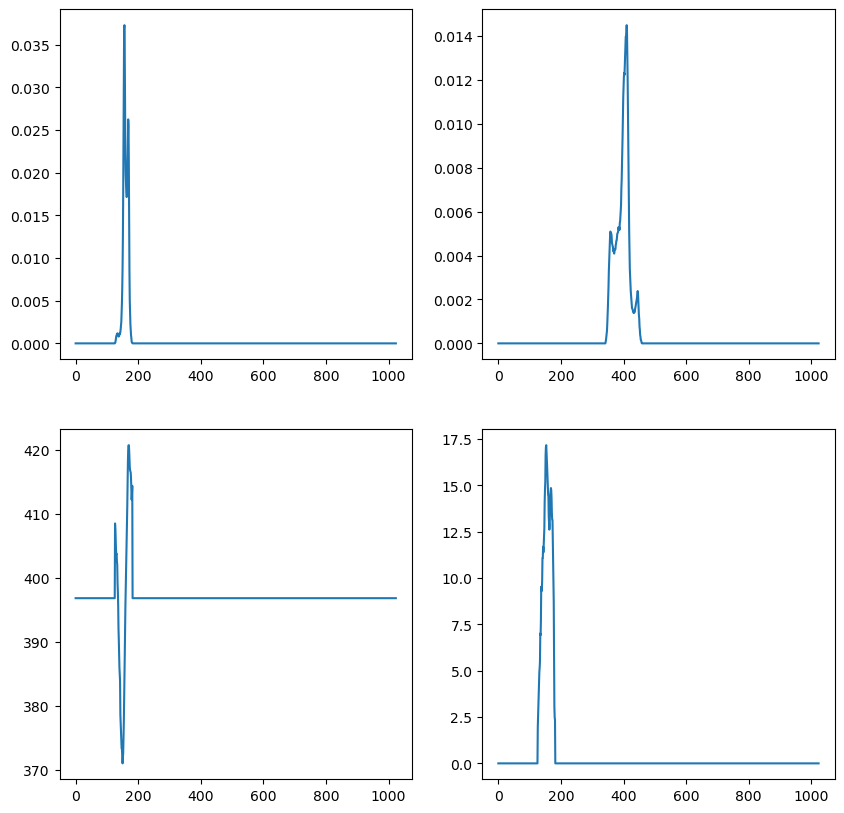

In [48]:
fig,((ax11,ax12),(ax21,ax22)) = plt.subplots(2,2,figsize=(10,10))
ax11.plot(x,imageStats['xProfile'])
ax12.plot(y,imageStats['yProfile'])
ax21.plot(y,imageStats['yCOMslice'])
ax22.plot(y,imageStats['yRMSslice'])
plt.show()

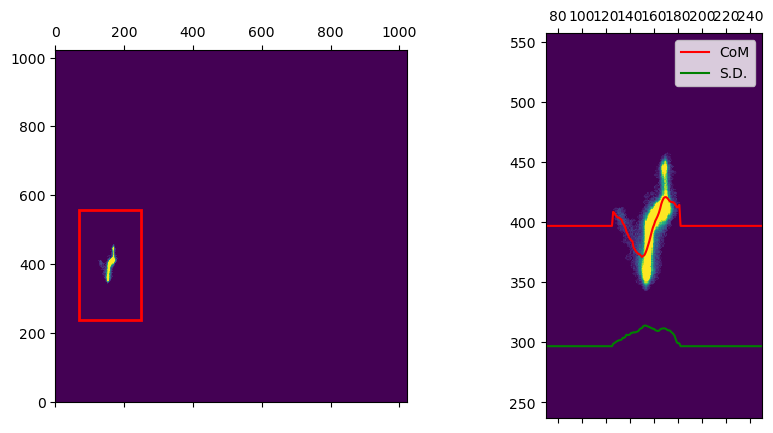

In [52]:
# Show
fig,(ax1,ax2) = xtpr.show_frame(
    frame,
    vrange=(0,3e-4),
    hist=False,
    fov=fov,
    returnfig = True
)
ax2.plot(y,imageStats['yCOMslice'],color='r',label='CoM')
ax2.plot(y,imageStats['yRMSslice']+imageStats['yCOM']-100,color='g',label='S.D.')
plt.legend()
plt.show()

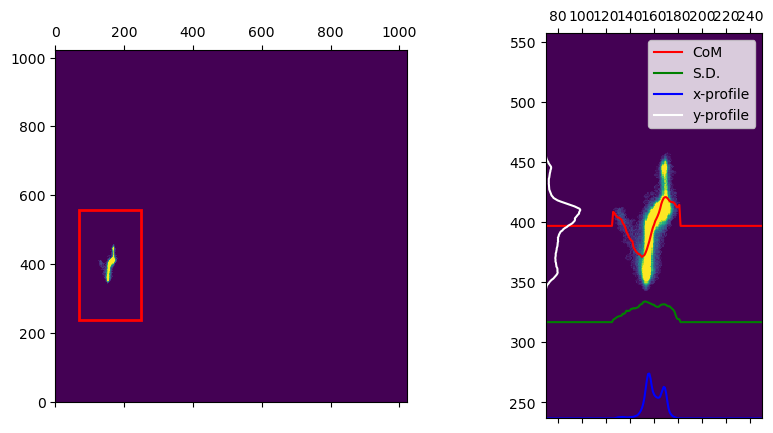

In [72]:
# Show
fig,(ax1,ax2) = xtpr.show_frame(
    frame,
    vrange=(0,3e-4),
    hist=False,
    fov=fov,
    returnfig = True
)
ax2.plot(y,imageStats['yCOMslice'],color='r',label='CoM')
ax2.plot(y,imageStats['yRMSslice']+imageStats['yCOM']-fov[1]/4,color='g',label='S.D.')
ax2.plot(y,1000*imageStats['xProfile']+imageStats['yCOM']-fov[1]/2,color='b',label='x-profile')
ax2.plot(2000*imageStats['yProfile']+imageStats['xCOM']-fov[0]/2,x,color='w',label='y-profile')
plt.legend()
plt.show()